In [1]:
# pip install prophet

In [2]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from prophet.plot import plot_plotly, plot_components_plotly
import plotly.graph_objects as go

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv(r"D:\1-First Insight\prediction\prophet\v1\MLdata\02_monthly_encounters.csv")
df.head()

,month_start,encounters
0,2018-07-01,78
1,2018-08-01,119
2,2018-09-01,132
3,2018-10-01,156
4,2018-11-01,137


In [4]:
df.columns = ["ds", "y"]

In [5]:
df

,ds,y
0,2018-07-01,78
1,2018-08-01,119
2,2018-09-01,132
3,2018-10-01,156
4,2018-11-01,137
...,...,...
95,2026-07-01,104
96,2026-08-01,118
97,2026-09-01,132
98,2026-10-01,110


In [6]:
# Disable seasonalities that don't apply to monthly data (avoids fitting noise)
m = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95  # 95% confidence band instead of default 80%
)

In [7]:
m.fit(df)

22:42:31 - cmdstanpy - INFO - Chain [1] start processing
22:42:31 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future = m.make_future_dataframe(periods=12, freq='MS')  

In [9]:
future

,ds
0,2018-07-01
1,2018-08-01
2,2018-09-01
3,2018-10-01
4,2018-11-01
...,...
107,2027-07-01
108,2027-08-01
109,2027-09-01
110,2027-10-01


In [10]:
forcast = m.predict(future)

In [11]:
forcast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
107,2027-07-01,109.996940,68.120628,147.553688
108,2027-08-01,109.978388,67.057216,155.692620
109,2027-09-01,109.959835,65.966673,154.414709
110,2027-10-01,109.941881,65.245014,150.371651
111,2027-11-01,109.923329,67.653348,152.949376


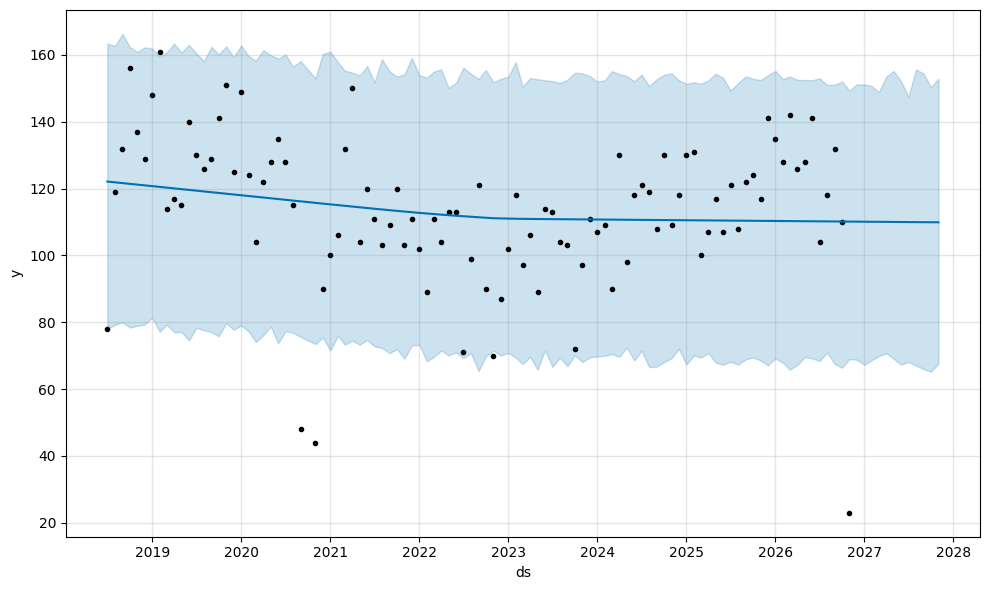

In [12]:
fig1 = m.plot(forcast)

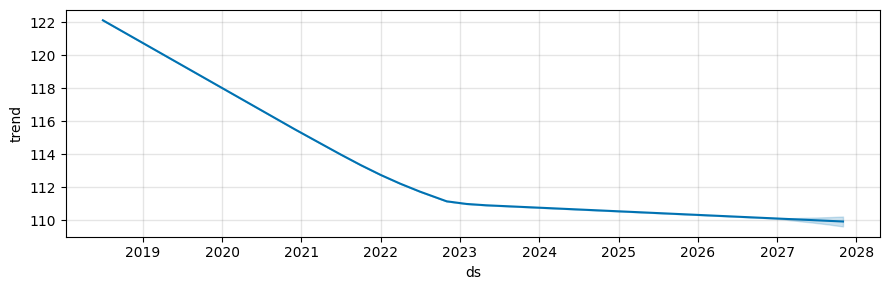

In [13]:
fig2 = m.plot_components(forcast)

  0%|          | 0/11 [00:00<?, ?it/s]22:42:34 - cmdstanpy - INFO - Chain [1] start processing
22:42:34 - cmdstanpy - INFO - Chain [1] done processing
  9%|▉         | 1/11 [00:00<00:02,  3.52it/s]22:42:34 - cmdstanpy - INFO - Chain [1] start processing
22:42:34 - cmdstanpy - INFO - Chain [1] done processing
 18%|█▊        | 2/11 [00:00<00:02,  3.39it/s]22:42:34 - cmdstanpy - INFO - Chain [1] start processing
22:42:34 - cmdstanpy - INFO - Chain [1] done processing
 27%|██▋       | 3/11 [00:00<00:02,  3.47it/s]22:42:34 - cmdstanpy - INFO - Chain [1] start processing
22:42:35 - cmdstanpy - INFO - Chain [1] done processing
 36%|███▋      | 4/11 [00:01<00:01,  3.51it/s]22:42:35 - cmdstanpy - INFO - Chain [1] start processing
22:42:35 - cmdstanpy - INFO - Chain [1] done processing
 45%|████▌     | 5/11 [00:01<00:01,  3.50it/s]22:42:35 - cmdstanpy - INFO - Chain [1] start processing
22:42:35 - cmdstanpy - INFO - Chain [1] done processing
 55%|█████▍    | 6/11 [00:01<00:01,  3.64it/s]22:42:35

     horizon      mape       rmse        mae
0    36 days  0.126119  16.946225  14.444234
1    40 days  0.115639  16.480082  13.523430
2    41 days  0.138985  18.028293  14.738572
3    45 days  0.140868  18.087185  14.894316
4    46 days  0.147153  18.707472  15.604608
..       ...       ...        ...        ...
115 355 days  0.193397  24.625885  21.227289
116 356 days  0.186422  22.857810  20.073634
117 360 days  0.175392  20.321747  18.443234
118 361 days  0.179910  21.306650  19.299158
119 365 days  0.434825  30.002123  23.306889

[120 rows x 4 columns]


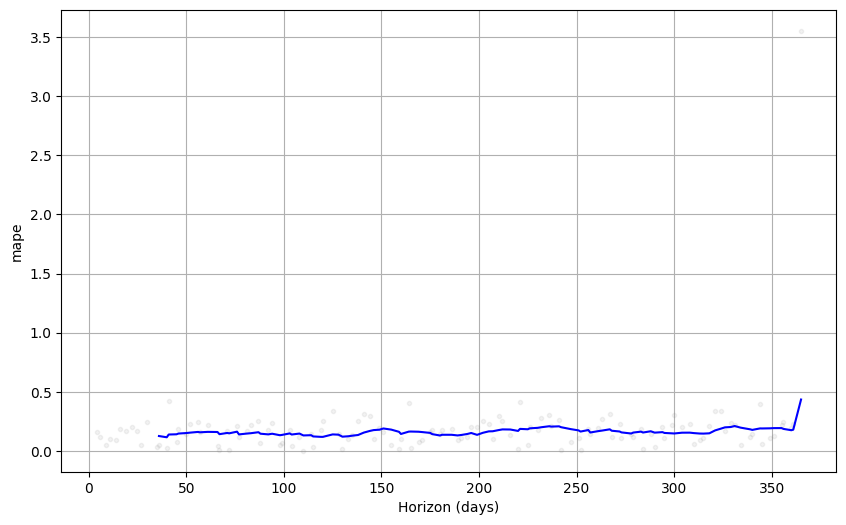

In [14]:
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

df_cv = cross_validation(
    m,
    initial='730 days',   # first ~2 years to train on
    period='180 days',    # re-test every 6 months
    horizon='365 days'    # forecast 1 year ahead each time, matching your real use case
)
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'mape', 'rmse', 'mae']])

fig3 = plot_cross_validation_metric(df_cv, metric='mape')

In [15]:
# pip install --upgrade nbformat

In [16]:
from prophet.plot import plot_plotly, plot_components_plotly

In [17]:
plot_plotly(m, forcast)